# Рубежный контроль №1
## Тема: Методы обработки данных

**Выполнил:** Ханунов Г.И
**Группа:** ИУ5-23М  
**Вариант:** 10  
**Задачи:** 10 и 30

---
## Загрузка и первичный анализ данных

Для выполнения работы используется набор данных **Penguins** из библиотеки `seaborn`.

**Описание признаков:**
- `species` — вид пингвина;
- `island` — остров, на котором проводилось наблюдение;
- `bill_length_mm` — длина клюва, мм;
- `bill_depth_mm` — глубина клюва, мм;
- `flipper_length_mm` — длина плавника, мм;
- `body_mass_g` — масса тела, г;
- `sex` — пол пингвина.

В признаке `sex` есть пропущенные значения, поэтому  используем это для 10. Для  30 в копию набора данных будут добавлены повторяющиеся признаки, после чего они будут найдены и удалены.

In [1]:
# Импорт библиотек
from pathlib import Path
import os

# Настройка локального кэша matplotlib внутри проекта
os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".cache" / "matplotlib").resolve())
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 20)

In [2]:
# Загрузка датасета из локального кэша seaborn
data_home = Path("data")
df = sns.load_dataset("penguins", data_home=str(data_home))

print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head(10)

Размер данных: 344 строк, 7 столбцов


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
missing_summary = pd.DataFrame({
    "Тип данных": df.dtypes.astype(str),
    "Количество пропусков": df.isna().sum(),
    "Доля пропусков, %": (df.isna().mean() * 100).round(2),
})
missing_summary

,Тип данных,Количество пропусков,"Доля пропусков, %"
species,str,0,0.00
island,str,0,0.00
bill_length_mm,float64,2,0.58
bill_depth_mm,float64,2,0.58
flipper_length_mm,float64,2,0.58
body_mass_g,float64,2,0.58
sex,str,11,3.20


In [5]:
df.describe(include="all")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


Построим диаграмму рассеяния для двух числовых признаков. Цветом обозначен вид пингвина.

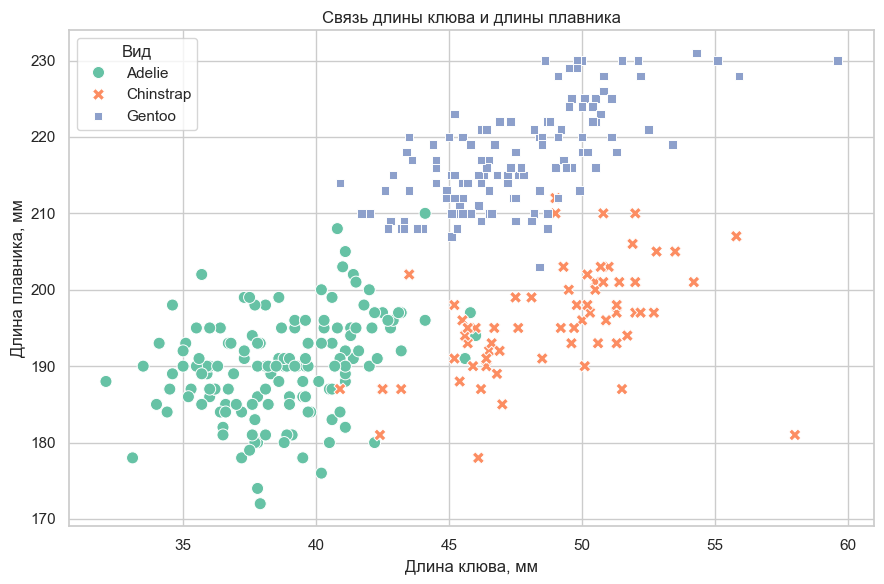

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="species",
    s=75,
)
plt.title("Связь длины клюва и длины плавника")
plt.xlabel("Длина клюва, мм")
plt.ylabel("Длина плавника, мм")
plt.legend(title="Вид")
plt.tight_layout()
plt.show()

Построим «ящик с усами» для признака `body_mass_g`.

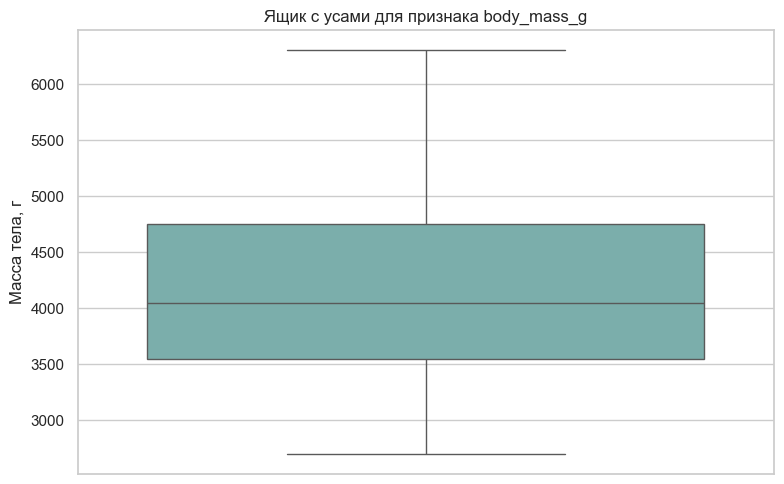

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="body_mass_g", color="#72B7B2")
plt.title("Ящик с усами для признака body_mass_g")
plt.ylabel("Масса тела, г")
plt.tight_layout()
plt.show()

---
## Задача №10: заполнение пропусков наиболее распространенным значением

Необходимо устранить пропуски в одном категориальном признаке методом заполнения наиболее распространенным значением. В качестве признака выбран `sex`.

In [8]:
df_task10 = df.copy()
feature = "sex"

missing_before = df_task10[feature].isna().sum()
most_common_value = df_task10[feature].mode(dropna=True).iloc[0]

print(f"Категориальный признак: {feature}")
print(f"Пропусков до обработки: {missing_before}")
print(f"Наиболее распространенное значение: {most_common_value}")

before_counts = df_task10[feature].fillna("Пропуск").value_counts()
before_counts.to_frame("Количество до обработки")

Категориальный признак: sex
Пропусков до обработки: 11
Наиболее распространенное значение: Male


,Количество до обработки
sex,
Male,168
Female,165
Пропуск,11


In [9]:
# Заполнение пропусков наиболее распространенным значением
df_task10[feature] = df_task10[feature].fillna(most_common_value)

missing_after = df_task10[feature].isna().sum()
print(f"Пропусков после обработки: {missing_after}")

after_counts = df_task10[feature].fillna("Пропуск").value_counts()
counts_comparison = pd.concat(
    [before_counts.rename("До обработки"), after_counts.rename("После обработки")],
    axis=1,
).fillna(0).astype(int)
counts_comparison

Пропусков после обработки: 0


,До обработки,После обработки
sex,,
Male,168,179
Female,165,165
Пропуск,11,0


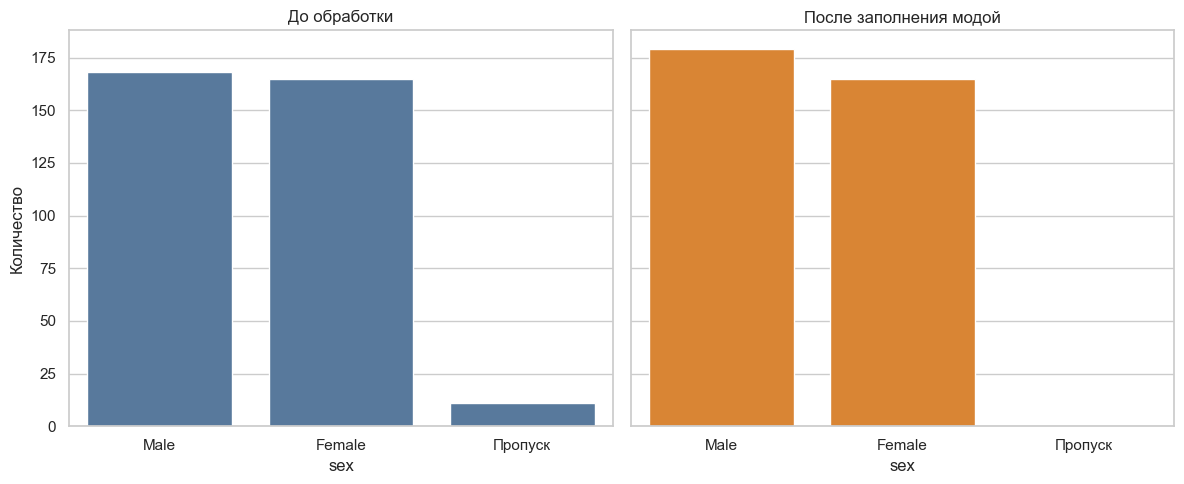

In [10]:
# Визуализация распределения категорий до и после заполнения
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
order = counts_comparison.index.tolist()

sns.countplot(x=df[feature].fillna("Пропуск"), order=order, ax=axes[0], color="#4C78A8")
axes[0].set_title("До обработки")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Количество")

sns.countplot(x=df_task10[feature].fillna("Пропуск"), order=order, ax=axes[1], color="#F58518")
axes[1].set_title("После заполнения модой")
axes[1].set_xlabel(feature)
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.show()

**Вывод по задаче №10.** Пропуски в категориальном признаке `sex` заполнены значением, которое встречается чаще всего. После обработки количество пропусков равно нулю.

---
## Задача №30: удаление повторяющихся признаков

Необходимо удалить признаки, которые полностью дублируют другие признаки набора данных. В исходном наборе таких признаков нет, поэтому для демонстрации в копию данных добавлены три повторяющихся столбца.

In [11]:
df_task30 = df.copy()

# Добавим повторяющиеся признаки
df_task30["bill_length_mm_copy"] = df_task30["bill_length_mm"]
df_task30["island_copy"] = df_task30["island"]
df_task30["body_mass_g_copy"] = df_task30["body_mass_g"]

print(f"Размер данных до удаления повторяющихся признаков: {df_task30.shape}")
df_task30.head()

Размер данных до удаления повторяющихся признаков: (344, 10)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_mm_copy,island_copy,body_mass_g_copy
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,39.1,Torgersen,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,39.5,Torgersen,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,40.3,Torgersen,3250.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,NaN,Torgersen,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,36.7,Torgersen,3450.0


In [12]:
# Поиск повторяющихся признаков
original_columns = []
duplicate_pairs = []

for column in df_task30.columns:
    duplicate_for = None
    for original in original_columns:
        if df_task30[column].equals(df_task30[original]):
            duplicate_for = original
            break

    if duplicate_for is None:
        original_columns.append(column)
    else:
        duplicate_pairs.append({
            "Повторяющийся признак": column,
            "Дублирует признак": duplicate_for,
        })

duplicate_pairs_df = pd.DataFrame(duplicate_pairs)
duplicate_pairs_df

,Повторяющийся признак,Дублирует признак
0,bill_length_mm_copy,bill_length_mm
1,island_copy,island
2,body_mass_g_copy,body_mass_g


In [13]:
# Удаление найденных повторяющихся признаков
duplicate_columns = duplicate_pairs_df["Повторяющийся признак"].tolist()
df_task30_clean = df_task30.drop(columns=duplicate_columns)

print(f"Удаленные признаки: {duplicate_columns}")
print(f"Размер данных после удаления повторяющихся признаков: {df_task30_clean.shape}")

removed_summary = pd.DataFrame({
    "Показатель": ["Количество признаков до", "Количество удаленных признаков", "Количество признаков после"],
    "Значение": [df_task30.shape[1], len(duplicate_columns), df_task30_clean.shape[1]],
})
removed_summary

Удаленные признаки: ['bill_length_mm_copy', 'island_copy', 'body_mass_g_copy']
Размер данных после удаления повторяющихся признаков: (344, 7)


,Показатель,Значение
0,Количество признаков до,10
1,Количество удаленных признаков,3
2,Количество признаков после,7


In [14]:
# Проверка, что повторяющихся признаков больше нет
remaining_duplicates = []
checked_columns = []

for column in df_task30_clean.columns:
    duplicate_for = None
    for checked in checked_columns:
        if df_task30_clean[column].equals(df_task30_clean[checked]):
            duplicate_for = checked
            break

    if duplicate_for is None:
        checked_columns.append(column)
    else:
        remaining_duplicates.append((column, duplicate_for))

print(f"Повторяющихся признаков после обработки: {len(remaining_duplicates)}")
remaining_duplicates

Повторяющихся признаков после обработки: 0


[]

**Вывод по задаче 30.** Найдены и удалены признаки `bill_length_mm_copy`, `island_copy`, `body_mass_g_copy`, которые полностью повторяли исходные столбцы. После обработки повторяющихся признаков не осталось.